In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import abel
 
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

avf_angles_exp = {'2.0': 10.1,
                  '3.3': 8.0,
                  '5.0': 8.0}

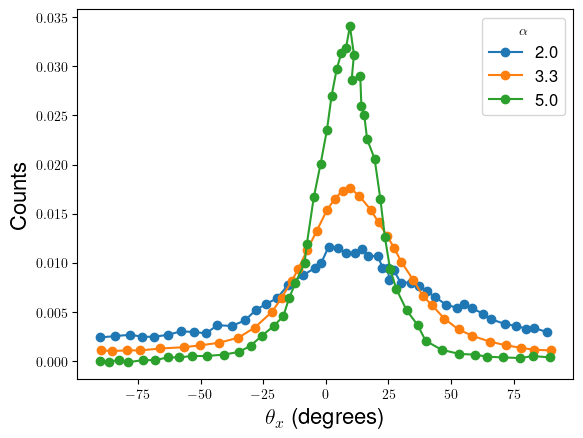

In [2]:
ap_list = np.array([2.0, 3.3, 5.0])
data_dict = {}
# read data from csv file as numpy array
for ap in ap_list:
    data = np.loadtxt(f'thetax_ap_{ap}.csv', delimiter=',', skiprows=0)
    data_dict[str(ap)] = data
    angles = data[:, 0]  # first column is angles
    hist = data[:, 1]  # second column is histogram values
    plt.plot(angles, hist, '-o', label='{:.1f}'.format(ap))

plt.xlabel(r'$\theta_x$ (degrees)', fontsize=16)
plt.ylabel('Counts', fontsize=16)
plt.legend(title=r'$\alpha$', fontsize=12)

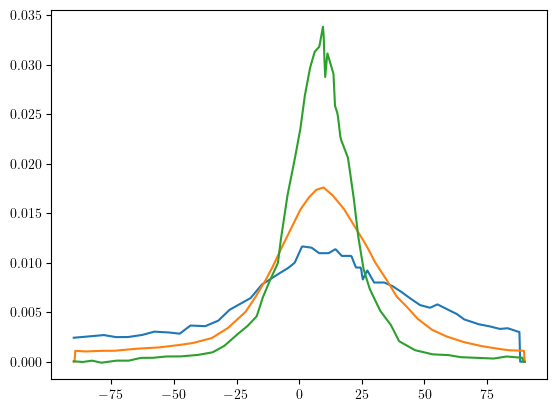

In [3]:
# 4. Interpolate to a uniform grid
num_points = 600
theta_uniform = np.linspace(-90, 90, num_points)
data_dict['theta_uniform'] = theta_uniform
for ap in ap_list:
    name_uniform = 'interp_' + str(ap)
    data_dict[name_uniform] = interp1d(data_dict[str(ap)][:, 0],
                                                    data_dict[str(ap)][:, 1], 
                                                    kind='linear', bounds_error=False, fill_value=0)(theta_uniform)

    plt.plot(theta_uniform, data_dict[name_uniform], label='orientation distribution interpolated')

In [4]:
# # find the circular mean of the angles distribution
# for ap in ap_list:
#     name_theta = 'interp_' + str(ap)
#     hist_uniform = data_dict[name_uniform]
#     theta_d = np.atan2(np.sum(np.sin(np.radians(theta_uniform)) * hist_uniform),
#                         np.sum(np.cos(np.radians(theta_uniform)) * hist_uniform))

#     theta_d = np.degrees(theta_d)  # convert to degrees
#     data_dict[name_theta] = theta_d
#     print(f'Circular mean of the angles distribution: {theta_d:.2f} degrees')

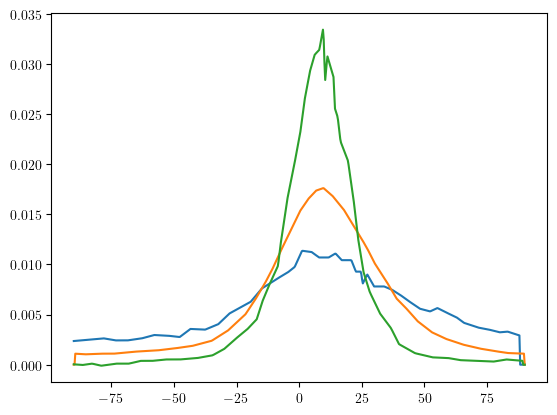

In [5]:
# normalize the interpolated histograms
for ap in ap_list:
    name_uniform = 'interp_' + str(ap)
    hist_uniform = data_dict[name_uniform]
    hist_uniform /= np.trapezoid(hist_uniform, theta_uniform)  # normalize
    name_normalized = 'normalized_' + str(ap)
    data_dict[name_normalized] = hist_uniform
    plt.plot(theta_uniform, hist_uniform, label='orientation distribution normalized')
    

In [6]:
# #make histogram symmetric

# # hist_sym = 0.5 * (hist_centered + np.flip(hist_centered))
# plt.plot(theta_uniform, hist_sym, label='final symmetric orientation distribution')
# plt.xlabel('Angle (degrees)')
# plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
# plt.legend()


In [7]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar
from scipy.optimize import brentq
from scipy.integrate import quad
from scipy.special import ellipe

def compute_v4_C_coefficient():
    """
    Computes the numerical coefficient for the v4,C term.
    Coefficient = (9/2) * integral_0_pi[ E(sin(theta)) * P4(cos(theta)) * sin(theta) ] d(theta)
    """
   
    def integrand(theta):
        # Handle the endpoints where sin(theta) = 0
        if theta == 0.0 or theta == np.pi:
            return 0.0

        x = np.cos(theta) # The argument for P4
        k = np.sin(theta) # The argument for E
        
        m = k**2
        E_k = ellipe(m)
        
        P4_x = P4(x)
        
        return E_k * P4_x * np.sin(theta)

    # 3. Perform the integration from 0 to pi
    # quad returns (integral_value, estimated_error)
    integral_value, error = quad(integrand, 0, np.pi)

    # 4. Calculate the final coefficient by multiplying by the prefactor
    prefactor = 9 / 2
    coefficient = prefactor * integral_value

    print(f"Numerical integral value: {integral_value:.10f}")
    print(f"Final Coefficient (9/2 * integral): {coefficient:.10f}")
    
    return coefficient

def find_U_from_S2(target_S2, u_min=0.01, u_max=150.0, tol=1e-7):
    """
    Finds the interaction strength U that self-consistently produces a
    target nematic order parameter S2.
    
    Uses a root-finding algorithm on the function g(U) = solve_self_consistent_S2(U) - target_S2.
    
    Args:
        target_S2 (float): The desired nematic order parameter (e.g., from simulation).
        u_min (float): The lower bound of the search interval for U.
        u_max (float): The upper bound of the search interval for U.
        tol (float): The tolerance for the root-finding.

    Returns:
        float: The self-consistent interaction strength U.
    """
    # Handle the trivial isotropic case where U is effectively zero.
    if target_S2 <= 0.01:
        return 0.0
        
    # Define the objective function whose root we want to find.
    # The root occurs when the S2 produced by a given U equals our target S2.
    def objective_func(U):
        return solve_self_consistent_S2(U) - target_S2
    
    try:
        # Use Brent's method, a robust and fast bracketing root-finder.
        U_solution = brentq(objective_func, u_min, u_max, xtol=tol)
        return U_solution
    except ValueError:
        # This error occurs if the objective function does not have opposite signs
        # at the ends of the interval, meaning there is no root to be found.
        # This can happen if the target_S2 is too high to be physically reachable.
        print(f"Warning: Could not find a self-consistent U for target S2 = {target_S2:.3f}. "
              "The target may be outside the reachable range.")
        return np.nan
    
def calculate_S2_from_distribution(thetas, U, S2_guess):
    """
    For a given interaction strength U and a guessed order parameter S2_guess,
    this function calculates the resulting order parameter by averaging P₂(cosθ)
    over the corresponding Maier-Saupe distribution.
    """
    cos_thetas = np.cos(thetas)
    
    # Calculate the un-normalized probability
    numerator = np.exp(U * S2_guess * P2(cos_thetas))
    
    # Integrand for the partition function Z (normalization constant)
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P2
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0
        
    # The new S2 is the correctly weighted average of P2 over the distribution
    S2_new = P2_integral / Z_integral
    return S2_new

def solve_self_consistent_S2(U, initial_guess=0.8, tol=1e-7, max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameter S2
    for a given interaction strength U.
    """
    S2 = initial_guess
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new = calculate_S2_from_distribution(thetas, U, S2)
        if np.abs(S2 - S2_new) < tol:
            return S2_new  # Converged
        S2 = S2_new
        
    # If max_iter is reached without convergence, it may be the isotropic state
    if S2 < 0.05: # A reasonable threshold for the isotropic phase
        return 0.0
        
    # print(f"Warning: Self-consistency for U={U:.2f} did not converge. Returning last value: {S2:.3f}")
    return S2

def fit_equilibrium_ODF(measured_thetas, S, U):
    """
    Maier-Saupe equilibrium distribution per unit solid angle,
    using the second Legendre Polynomial P₂(cosθ).
    Accounts for head-tail symmetry (θ ∈ [0, π/2]).
    Normalization is computed over [0, π/2] and multiplied by 2 to account for symmetry.
    """
    cos_thetas = np.cos(measured_thetas)
    
    legendre_term = P2(cos_thetas)
    
    numerator = np.exp(S * U * legendre_term)
    
    integrand = numerator * np.sin(measured_thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=measured_thetas)
    
    return numerator / denominator

def fit_equilibrium_ODF_P4(thetas, order_params, interaction_params):
    """
    Equilibrium distribution f(θ) using both P₂ and P₄ terms.
    f(θ) = exp(U₂S₂P₂ + U₄S₄P₄) / Z
    """
    S2, S4 = order_params
    U2, U4 = interaction_params
    cos_thetas = np.cos(thetas)

    potential = U2 * S2 * P2(cos_thetas) + U4 * S4 * P4(cos_thetas)
    numerator = np.exp(potential)

    integrand = numerator * np.sin(thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=thetas)

    return numerator / denominator


def P2(x):
    """Calculates the second Legendre polynomial, P₂(x) = (3x² - 1)/2."""
    return 0.5 * (3 * x**2 - 1.0)

def P4(x):
    """Calculates the fourth Legendre polynomial, P₄(x) = (35x⁴ - 30x² + 3)/8."""
    return (35 * x**4 - 30 * x**2 + 3) / 8.0

def excluded_volume_rod_P2(alpha):
    second_coeff_A_complete = -5 / 32 * np.pi * (8*alpha / np.pi + 2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi)
    second_coeff_B_complete = 5/8 *2
    second_coeff_C_complete = 0.385*8/np.pi
    return (second_coeff_A_complete + second_coeff_B_complete + second_coeff_C_complete)

def excluded_volume_rod_P4(alpha):
    fourth_coeff_A_complete = -9/256 * np.pi * (8*alpha / np.pi + 2/alpha)
    fourth_coeff_B_complete = -3/16 * 2
    fourth_coeff_C_complete = -0.06505 * 8/np.pi
    return (fourth_coeff_A_complete + fourth_coeff_B_complete + fourth_coeff_C_complete)

def compute_correction_density(phi):
    """
    Computes the Parsons-Lee correction factor for a given volume fraction phi
    """
    return phi*(1-3/4*phi) / (1-phi)**2

def calculate_S2_S4_from_distribution_p4(thetas, interaction_params, order_params_guess):
    """
    For a given set of interaction strengths (U₂, U₄) and a guessed
    set of order parameters (S₂_guess, S₄_guess), this function
    calculates the resulting order parameters by averaging P₂(cosθ)
    and P₄(cosθ) over the corresponding equilibrium distribution.
    
    *** This version is robust to numerical overflow. ***
    """
    U2, U4 = interaction_params
    S2_guess, S4_guess = order_params_guess
    cos_thetas = np.cos(thetas)
    
    # Calculate the potential
    potential = U2 * S2_guess * P2(cos_thetas) + U4 * S4_guess * P4(cos_thetas)
    V_max = np.max(potential)
    
    # Subtract V_max before exponentiating to prevent overflow
    numerator = np.exp(potential - V_max)
 
    # Integrand for the partition function Z 
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P₂
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)

    # Integrand for the average of P₄
    integrand_P4 = P4(cos_thetas) * numerator * np.sin(thetas)
    P4_integral = np.trapezoid(integrand_P4, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0, 0.0
        
    S2_new = P2_integral / Z_integral
    S4_new = P4_integral / Z_integral
    
    return S2_new, S4_new

def solve_self_consistent_S2_S4_p4(interaction_params,
                                   initial_guesses=(0.8, 0.4),
                                   tol=1e-7,
                                   max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameters S₂ and S₄
    for a given set of interaction strengths (U₂, U₄).
    """
    S2, S4 = initial_guesses
    
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new, S4_new = calculate_S2_S4_from_distribution_p4(thetas,
                                                              interaction_params,
                                                              (S2, S4))
        
        # Check for convergence in *both* parameters
        if (np.abs(S2 - S2_new) < tol) and (np.abs(S4 - S4_new) < tol):
            return S2_new, S4_new  # Converged
            
        S2, S4 = S2_new, S4_new
        
    # If max_iter is reached, check if it's the isotropic state
    if (S2 < 0.05) and (np.abs(S4) < 0.05):
        print("Warning: Self-consistency reached isotropic state.")
        return 0.0, 0.0
        
    print(f"Warning: Self-consistency for U₂={U2:.2f}, U₄={U4:.2f} did not converge. "
          f"Returning last values: S₂={S2:.3f}, S₄={S4:.3f}")
    return S2_new, S4_new

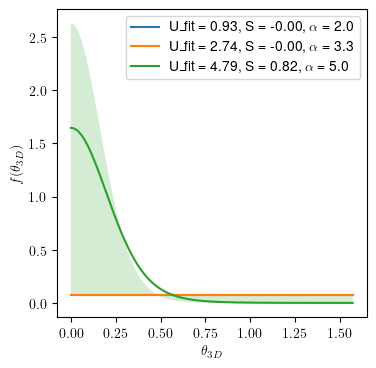

In [8]:
S_given = np.array([0.27, 0.72, 0.81]) # pure experimental values
density = np.array([0.495, 0.5, 0.48]) # experimental densities for the three alphas
# density = np.array([0.59346873, 0.58252208, 0.55931669]) # densities from the simulations
alphas = np.array([2.0, 3.3, 5.0])

uncertainty = 0.1
corrections_density = [compute_correction_density(phi) for phi in density]
corrections_density_low = [compute_correction_density(phi*(1-uncertainty)) for phi in density]
corrections_density_high = [compute_correction_density(phi*(1+uncertainty)) for phi in density]
excluded_volume_rods_P2 = [excluded_volume_rod_P2(alpha) for alpha in alphas]
U2s_theoretical = [ -corrections_density[i] * excluded_volume_rods_P2[i] for i in range(len(alphas))]
U4s_theoretical = [ -corrections_density[i] * excluded_volume_rod_P4(alphas[i]) for i in range(len(alphas))]
U2s_theoretical_low = [ -corrections_density_low[i] * excluded_volume_rods_P2[i] for i in range(len(alphas))]
U4s_theoretical_low = [ -corrections_density_low[i] * excluded_volume_rod_P4(alphas[i]) for i in range(len(alphas))]
U2s_theoretical_high = [ -corrections_density_high[i] * excluded_volume_rods_P2[i] for i in range(len(alphas))]
U4s_theoretical_high = [ -corrections_density_high[i] * excluded_volume_rod_P4(alphas[i]) for i in range(len(alphas))]
S2_theoretical, S4_theoretical, S2_theoretical_low, S2_theoretical_high, S4_theoretical_low, S4_theoretical_high = [], [], [], [], [], []

for i in range(len(alphas)):
    interaction_params = (U2s_theoretical[i], U4s_theoretical[i])
    S2_sol, S4_sol = solve_self_consistent_S2_S4_p4(interaction_params)
    S2_theoretical.append(S2_sol)
    S4_theoretical.append(S4_sol)
    S2_sol_low, S4_sol_low = solve_self_consistent_S2_S4_p4((U2s_theoretical_low[i], U4s_theoretical_low[i]))
    S2_theoretical_low.append(S2_sol_low)
    S4_theoretical_low.append(S4_sol_low)
    S2_sol_high, S4_sol_high = solve_self_consistent_S2_S4_p4((U2s_theoretical_high[i], U4s_theoretical_high[i]))
    S2_theoretical_high.append(S2_sol_high)
    S4_theoretical_high.append(S4_sol_high)

theta_vals = np.linspace(0, np.pi/2, 1000)

plt.figure(figsize=(4,4))
for i, alpha in enumerate(alphas):
    # Plot the distribution
    name_theory = 'theory_' + str(alpha)
    name_theory_low = 'theory_low_' + str(alpha)
    name_theory_high = 'theory_high_' + str(alpha)
    f_vals = fit_equilibrium_ODF_P4(
        theta_vals,
        order_params=(S2_theoretical[i], S4_theoretical[i]),
        interaction_params=(U2s_theoretical[i], U4s_theoretical[i])
    )
    f_vals_low = fit_equilibrium_ODF_P4(
        theta_vals,
        order_params=(S2_theoretical_low[i], S4_theoretical_low[i]),
        interaction_params=(U2s_theoretical_low[i], U4s_theoretical_low[i])
    )
    f_vals_high = fit_equilibrium_ODF_P4(
        theta_vals,
        order_params=(S2_theoretical_high[i], S4_theoretical_high[i]),
        interaction_params=(U2s_theoretical_high[i], U4s_theoretical_high[i])
    )
    data_dict[name_theory] = f_vals
    data_dict[name_theory_low] = f_vals_low
    data_dict[name_theory_high] = f_vals_high
    plt.plot(theta_vals , f_vals, label=f"U_fit = {U2s_theoretical[i]:.2f}, S = {S2_theoretical[i]:.2f}, $\\alpha$ = {alpha:.1f}")
    plt.fill_between(theta_vals, f_vals_low, f_vals_high, alpha=0.2)
    
plt.xlabel("$\\theta_{3D}$") 
plt.ylabel("$f(\\theta_{3D})$")
# plt.title(f"Maier–Saupe distribution for S = {S_given}")
plt.legend()
plt.show()


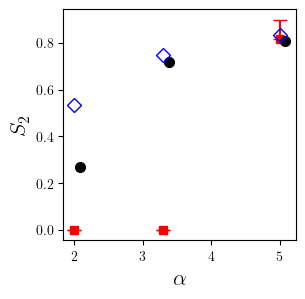

In [15]:
S2_sims_mean = np.array([0.5351339744031801,0.7502865632772305, 0.8326674212099459])

plt.figure(figsize=(3,3))
plt.plot(ap_list, S2_theoretical, 's', label='Equilibrium', color='r')
# err_low = np.array(S2_theoretical) - np.array(S2_theoretical_low)
err_low = np.zeros_like(S2_theoretical) 
err_high = np.array(S2_theoretical_high) - np.array(S2_theoretical)
# remove negative errors due to numerical issues
err_low = np.where(err_low < 0, 0, err_low)
err_high = np.where(err_high < 0, 0, err_high)

plt.errorbar(ap_list, S2_theoretical,
                yerr=[err_low, err_high],
                fmt='none', ecolor='r', capsize=5)
plt.plot(ap_list + 0.08, S_given, 'o', markerfacecolor = 'k', markeredgecolor='k',
         markersize=7, label=r'\textit{Wegner 2012}')
plt.plot(ap_list, S2_sims_mean, 'D', markerfacecolor = 'none', markeredgecolor='b',
         markersize=7, label=r'\textit{Simulations}')

plt.xlabel(r'$\alpha$', fontsize=16)
plt.ylabel(r'$S_2$', fontsize=16)
# plt.legend(loc='center', fontsize=12)
plt.savefig('S2_vs_alpha_rods.pdf', bbox_inches='tight', dpi=300)

In [10]:
from scipy.interpolate import interp1d

# Define the g(theta_2D) function
def g2d(theta_2D, f_interpolator):
    cos_theta = np.cos(theta_2D)
    
    # Handle cases at +/- 90 deg
    if cos_theta <= 1e-9:
        return 0.0
        
    abs_cos_theta = np.abs(cos_theta)
    
    # Integrand
    def integrand(t):
        sqrt_arg = cos_theta**2 - t**2
        if sqrt_arg <= 1e-15: # Avoid division by zero at the edge
            return 0.0
        
        # 1. Get the 3D angle (in radians)
        theta_3d = np.arccos(t)
        
        # 2. Get f by calling the interpolator function
        f_val = f_interpolator(theta_3d)

        return t * f_val / np.sqrt(sqrt_arg)

    # Numerical integration from 0 to cos(theta_2D)
    # Added 'limit' to help with the singularity
    integral, err = quad(integrand, 0, cos_theta, limit=100)

    # Compute g
    return (1 / (np.pi * abs_cos_theta)) * integral

/tmp/ipykernel_11159/1387369134.py:29: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, err = quad(integrand, 0, cos_theta, limit=100)
/tmp/ipykernel_11159/1387369134.py:29: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  integral, err = quad(integrand, 0, cos_theta, limit=100)


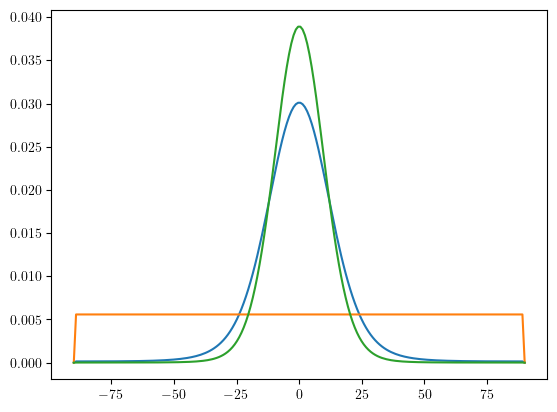

In [11]:
f_vals_length = len(data_dict['theory_'+str(ap_list[2])]) # Get length from one
theta_3d_axis = np.linspace(0, np.pi/2, f_vals_length)

theta_2D_vals = np.linspace(-np.pi/2, np.pi/2, 200)
theta_deg = np.rad2deg(theta_2D_vals)
data_dict['theta_2D_vals'] = theta_2D_vals

for i, ap in enumerate(ap_list[2:]):
    for name in ['_', '_low_', '_high_']:
        # Get the raw 3D data (the green curve's y-values)
        f_3d_samples = data_dict['theory' + name +str(ap)]
        
        # 1. Create the interpolator for this f(theta_3D)
        f_interp = interp1d(theta_3d_axis, 
                            f_3d_samples, 
                            bounds_error=False, 
                            fill_value=0.0)
        
        # 2. Pass the *interpolator function* to g2d
        g_vals = [g2d(theta_2D, f_interp) for theta_2D in theta_2D_vals]
        g_vals = np.array(g_vals)
        
        # Check for NaNs/Infs which can happen if integration fails
        g_vals = np.nan_to_num(g_vals) 

        # 3. Normalize
        # Make sure to integrate against radians if your function expects radians
        g_vals /= np.trapezoid(g_vals, theta_deg) 
        
        data_dict['g2d' + name + str(ap)] = g_vals
        
        # Your plot command used degrees, so we still convert for plotting
        plt.plot(theta_deg, g_vals, label=f"α = {ap:.1f}")

In [12]:
data_dict.keys()

dict_keys(['2.0', '3.3', '5.0', 'theta_uniform', 'interp_2.0', 'interp_3.3', 'interp_5.0', 'normalized_2.0', 'normalized_3.3', 'normalized_5.0', 'theory_2.0', 'theory_low_2.0', 'theory_high_2.0', 'theory_3.3', 'theory_low_3.3', 'theory_high_3.3', 'theory_5.0', 'theory_low_5.0', 'theory_high_5.0', 'theta_2D_vals', 'g2d_5.0', 'g2d_low_5.0', 'g2d_high_5.0'])

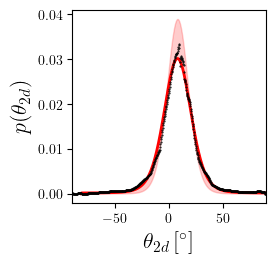

In [13]:
# shift the predicted curves by the experimental avf angles
plt.figure(figsize=(2.5,2.5))
for i, ap in enumerate(ap_list[2:]):
    # shift theta_2D_vals by the experimental avf angle
    shifted_theta_2D = theta_deg + avf_angles_exp[str(ap)]
    g_vals_shifted = data_dict['g2d_' + str(ap)] 
    # g_vals_shifted_low = data_dict['g2d_low_' + str(ap)]
    g_vals_shifted_low = g_vals_shifted
    g_vals_shifted_high = data_dict['g2d_high_' + str(ap)]
    plt.plot(shifted_theta_2D, g_vals_shifted, 'r-', label=f"Equilibrium", linewidth=2)
    plt.fill_between(shifted_theta_2D, g_vals_shifted_low, g_vals_shifted_high, color='r', alpha=0.2)
    plt.plot(data_dict['theta_uniform'], data_dict['normalized_' + str(ap)], 'ko', label=r"\textit{Wegner 2012}", markersize=0.5)
plt.xlim(-90, 90)
plt.xlabel(r'$\theta_{2d} \, [^\circ]$ ', fontsize=16)
plt.ylabel(r'$p(\theta_{2d})$', fontsize=16)
# plt.legend(fontsize=12, loc='upper right')
plt.savefig('orientation_distribution_comparison_rods.pdf', bbox_inches='tight', dpi=300)


In [14]:
g_vals_shifted_high

array([0.00000000e+00, 1.52063020e-05, 1.52104558e-05, 1.52175575e-05,
       1.52278674e-05, 1.52417634e-05, 1.52597096e-05, 1.52823007e-05,
       1.53101557e-05, 1.53442494e-05, 1.53852768e-05, 1.54343213e-05,
       1.54925373e-05, 1.55613882e-05, 1.56414100e-05, 1.57349500e-05,
       1.58433557e-05, 1.59684045e-05, 1.61120907e-05, 1.62765330e-05,
       1.64641550e-05, 1.66775244e-05, 1.69196553e-05, 1.71937740e-05,
       1.75035224e-05, 1.78528658e-05, 1.82465262e-05, 1.86898218e-05,
       1.91884737e-05, 1.97493903e-05, 2.03802869e-05, 2.10900184e-05,
       2.18887920e-05, 2.27887640e-05, 2.38039066e-05, 2.49491126e-05,
       2.62441139e-05, 2.77106198e-05, 2.93735955e-05, 3.12650308e-05,
       3.34186776e-05, 3.58776697e-05, 3.86906676e-05, 4.19191828e-05,
       4.56319213e-05, 4.99134894e-05, 5.48643619e-05, 6.06046259e-05,
       6.72785353e-05, 7.50579881e-05, 8.41512528e-05, 9.48073442e-05,
       1.07326029e-04, 1.22067998e-04, 1.39468324e-04, 1.60048603e-04,
      

In [16]:
import numpy as np

In [18]:
x = np.linspace(0, 10, 100)
x

array([ 0.        ,  0.1010101 ,  0.2020202 ,  0.3030303 ,  0.4040404 ,
        0.50505051,  0.60606061,  0.70707071,  0.80808081,  0.90909091,
        1.01010101,  1.11111111,  1.21212121,  1.31313131,  1.41414141,
        1.51515152,  1.61616162,  1.71717172,  1.81818182,  1.91919192,
        2.02020202,  2.12121212,  2.22222222,  2.32323232,  2.42424242,
        2.52525253,  2.62626263,  2.72727273,  2.82828283,  2.92929293,
        3.03030303,  3.13131313,  3.23232323,  3.33333333,  3.43434343,
        3.53535354,  3.63636364,  3.73737374,  3.83838384,  3.93939394,
        4.04040404,  4.14141414,  4.24242424,  4.34343434,  4.44444444,
        4.54545455,  4.64646465,  4.74747475,  4.84848485,  4.94949495,
        5.05050505,  5.15151515,  5.25252525,  5.35353535,  5.45454545,
        5.55555556,  5.65656566,  5.75757576,  5.85858586,  5.95959596,
        6.06060606,  6.16161616,  6.26262626,  6.36363636,  6.46464646,
        6.56565657,  6.66666667,  6.76767677,  6.86868687,  6.96

In [19]:
y = x**2

In [22]:
y.shape
x.shape

(100,)

In [24]:
!pip install jax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.1 MB/s  0:00:002.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 MB 6.1 MB/s  0:00:13 eta 0:00:010:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.9 MB/s  0:00:02m 1.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [jax]━━━━━━━ 3/4 [jax]ib]es]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [51]:
import jax
import jax.numpy as jnp
vv = lambda x, y: jnp.vdot(x, y)  #  ([a], [a]) -> []
mv = jax.vmap(vv, (1, 0), 1)      #  ([b,a], [a]) -> [b]      (b is the mapped axis)
mm = jax.vmap(mv, (None, 1), 1)      #  ([b,a], [a,c]) -> [b,c]  (c is the mapped axis)

In [49]:
x = jnp.diag(jnp.arange(0, 100))  # shape (100, 100)
y = jnp.diag(jnp.arange(0, 100))  # shape (100, 100)

In [52]:
mv(x, y).shape

ValueError: axis 1 is out of bounds for array of dimension 1